In [55]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

In [56]:
from IPython.display import display, Latex

# Define your LaTeX macros
latex_macros = r"""
\newcommand{\expval}[1]{\langle #1 \rangle}
"""

# Display the macros so that they are available throughout the notebook
display(Latex(f"$${latex_macros}$$"))

<IPython.core.display.Latex object>

# Density Branches

This notebook drafts some approaches to defining a branch factor for quantum states that are really produced in the lab, taking into account noise.

Consider two pure pointer states $|\psi_1\rangle$ and $|\psi_2\rangle$. We aim to produce the state $$\frac{1}{\sqrt{2}}|\psi_1\rangle + \frac{1}{\sqrt{2}}|\psi_2\rangle$$ but what we actually produce in the lab is the density matrix $\rho$.

### Quantum Fidelity

**Definition**: The quantum fidelity $F(|\psi\rangle, \rho)$ between a pure state $|\psi\rangle$ and a density matrix $\rho$ is given by:

$$
F(|\psi\rangle, \rho) = \langle\psi| \rho |\psi\rangle
$$

This fidelity directly represents the probability that a measurement of the state $\rho$ will find it in the state $|\psi\rangle$.

**Lower Bound**: The value of $F(|\psi\rangle, \rho)$ gives a lower bound on the probability that the state $\rho$ corresponds to the pure state $|\psi\rangle$.

In [57]:
# Define the pure states |psi_1, psi_2> (example)
psi_1 = np.array([1, 0, 0, 0])  # Example: |00>
psi_2 = np.array([0, 0, 0, 1])  # Example: |11>
psi = 1/np.sqrt(2)*psi_1 + 1/np.sqrt(2)*psi_2

# Define the noisy density matrix rho (example)
rho = np.array([[0.9, 0.1, 0.1, 0.1],
                [0.1, 0.05, 0.02, 0.02],
                [0.1, 0.02, 0.03, 0.02],
                [0.1, 0.02, 0.02, 0.02]])

# Ensure rho is Hermitian
rho = (rho + rho.T.conj()) / 2

# Calculate fidelity
fidelity = np.vdot(psi, np.dot(rho, psi))

print(f"Fidelity with |psi>: {fidelity}")
print(f"This means there is greater than a {fidelity*100:.2f}% probability that the state psi was prepared")

Fidelity with |psi>: 0.5599999999999998
This means there is greater than a 56.00% probability that the state psi was prepared


### Fidelity of LF Violations
Using this fidelity can give us a probability that we have the intended branch factor. However, in our experiments we need to show that we have both prepared the intended branch factor AND violated local friendliness with those same states. We need to avoid a scenario where it is the incorrect states are the ones dominating the expecation values that contribute to the local friendlieness violation.

Let $p$ be the probability that our target pure state was prepared. This is lower bounded by the fidelity.

Consider a proposed experimental violation of the Semi-Brukner inequality:
$$
X:= -\expval{A_1B_2}+\expval{A_1B_3}-\expval{A_3B_2}-\expval{A_3B_3}\ge 2
$$

To bound the value of $ X $ as a function of the probability $ p $ that the data going into the expectation is valid, we need to consider the worst-case scenario for the expectation values given the bounds and the probability $ 1 - p $ of invalid data.

1. **Expectation Value Bounds:**
   Each expectation value $ \expval{A_i} $ and $ \expval{B_j} $ is bounded between -1 and 1. If there is a probability $ p $ that the data is invalid, the invalid data might skew the expectation values.

2. **Impact of Invalid Data:**
   For invalid data, we assume the worst-case scenario where the invalid data maximizes or minimizes each term in $ X $. Specifically, we consider:
   - The valid data contributes expectation values within the range [-1, 1].
   - The invalid data contributes values that skew the expectation values towards the extremes.

3. **Bounds on $ X $:**
   Given $ p $ is the probability of valid data, the effective expectation value can be modeled as a mixture:
   $$
   \expval{A_i} = p \expval{A_i}^{\text{valid}} + (1-p) \expval{A_i}^{\text{invalid}}
   $$
   Similarly for $ \expval{B_j} $, $ \expval{A_i B_j} $, etc. In the worst-case scenario, the invalid contributions could be at the bounds (-1 or 1).
   Let $\expval{\tilde{A_i}}$ be the measured expectation value. This means that 
$$
   \expval{A_i}^{\text{valid}} = \frac{\expval{\tilde{A_i}} - (1-p) \expval{A_i}^{\text{invalid}}}{p}
$$
We then set $\expval{A_i}^{\text{invalid}}$ to whatever is the worst case for that term in $X$.

#### Worst-Case Analysis
For the positive term: $\expval{A_1 B_3}$ we have 
$$
\begin{align}
   \expval{A_1 B_3}^{\text{valid}} &= \frac{\expval{\tilde{A_1 B_3}} - (1-p) \expval{A_1 B_3}^{\text{invalid}}}{p}\\
   \expval{A_1 B_3}^{\text{valid}} &\ge \frac{\expval{\tilde{A_1 B_3}} - (1-p)*2}{p}
\end{align}
$$

For the negative terms we have
$$
\begin{align}
   -\expval{A_i}^{\text{valid}} &= \frac{(1-p) \expval{A_i}^{\text{invalid}}-\expval{\tilde{A_i}}}{p} \\
   -\expval{A_i}^{\text{valid}} &\ge \frac{(1-p)*(-2)-\expval{\tilde{A_i}}}{p} 
   = \frac{2(p-1)-\expval{\tilde{A_i}}}{p}
\end{align}
$$
and similarly for the $B_i$ and $AB$ terms.

This gives 
$$
\begin{align}
X^{\text{valid}}&:= -\expval{A_1B_2}^{\text{valid}}+\expval{A_1B_3}^{\text{valid}}-\expval{A_3B_2}^{\text{valid}}-\expval{A_3B_3}^{\text{valid}} \\
X^{\text{valid}}&\ge 
\frac{1}{p} \left[
2(p-1)-\expval{\tilde{A_1B_2}}
+\expval{\tilde{A_1 B_3}} - (1-p)*2
+2(p-1)-\expval{\tilde{A_3B_2}}
+2(p-1)-\expval{\tilde{A_3B_3}}
\right] \\
X^{\text{valid}}&\ge
\frac{1}{p} \left[
\tilde{X}
+8(p-1)
\right]
\end{align}
$$

It is this value of $X^{\text{valid}}$ that matters to show the violation under noise. We must have:
$$
X^{\text{valid}} \ge 2
$$
or similarly that the measured value
$$
\begin{align}
\tilde{X} &\ge 2p - 8(p-1) \\
\tilde{X} &\ge 8 - 6p
\end{align}
$$

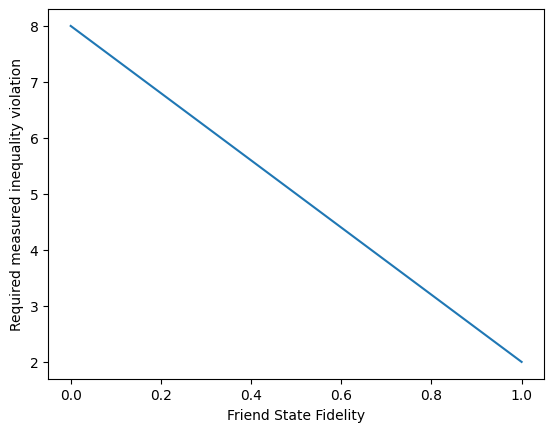

In [58]:
probs = np.linspace(0, 1, 5)
x_tilde = [(8 - 6*p) for p in probs]

plt.xlabel("Friend State Fidelity")
plt.ylabel("Required measured inequality violation")
_ = plt.plot(probs, x_tilde)

The maximum value for the Semi-Brukner inequality is 2.380364. Solving for this gives:

In [59]:
p_threshold = (8 - 2.380364) / 6
print("If we have no model for the errors, then the friend state fidelity must be above", p_threshold)

If we have no model for the errors, then the friend state fidelity must be above 0.9366059999999999


## Note that we also will need to adjust the error bars on violations because we will be throwing out samples with probability 1-p. Error bars should come from assuming only p*T samples where T is the number of trials

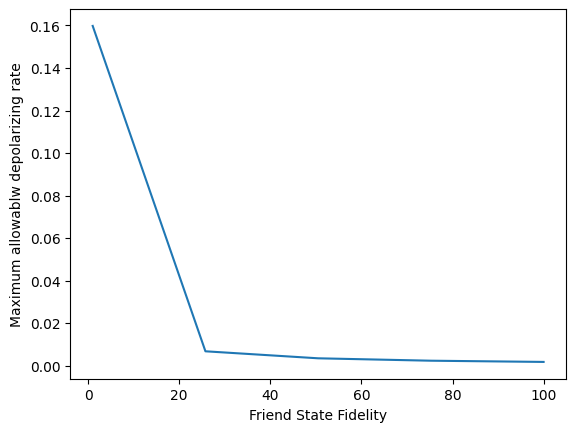

In [60]:
ls = np.linspace(1, 100, 5)
x_tilde = [1-(2/2.380364)**(1/l) for l in ls]

plt.xlabel("Friend State Fidelity")
plt.ylabel("Maximum allowablw depolarizing rate")
_ = plt.plot(ls, x_tilde)

In [61]:
x_tilde

[0.159792367889953,
 0.006738600363997871,
 0.0034417119344577474,
 0.0023110295906160205,
 0.0017395475962052043]

## Plots

In [62]:
import math

In [63]:
# We assume a depolarizing noise model
m = 10 # number of gates
p = 0.01 # per gate depolarizing rate

def max_allowed_p(m):
    return 1-(2/2.380364)**(1/m)

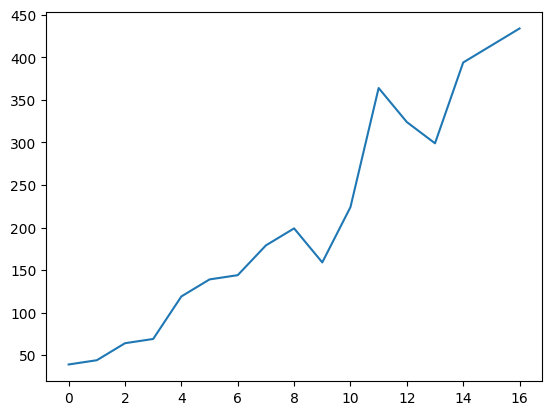

In [64]:
gate_counts_by_friend_size = [39, 44, 64, 69, 119, 139, 144, 179, 199, 159, 224, 364, 324, 299, 394, 414, 434]
# note these are compiled
plt.plot(gate_counts_by_friend_size)

In [65]:
state_fidelities_depol = [0.9941, 0.9932, 0.9897, 0.9888, 0.9799, 0.9764, 0.9755, 0.9694,0.9659, 0.9729, 0.9616, 0.9376, 0.9444, 0.9487, 0.9326, 0.9292, 0.9259]

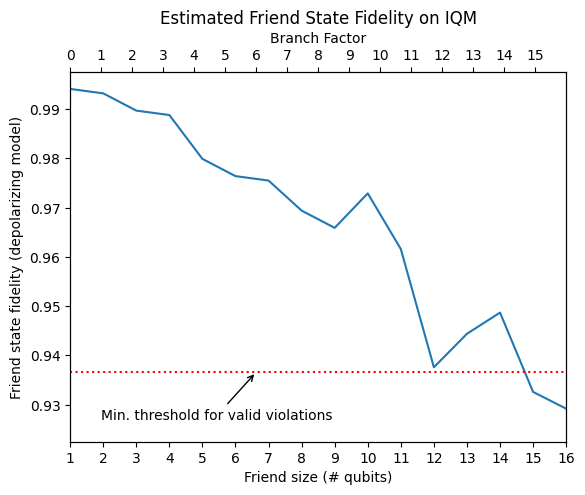

In [79]:
# Create a plot
fig, ax1 = plt.subplots()

# Plot data on the main x-axis
xs = np.asarray(range(len(state_fidelities_depol))) + 1
ax1.plot(xs, state_fidelities_depol)
ax1.set_xticks(xs)
ax1.set_xlabel('Friend size (# qubits)')
ax1.set_ylabel('Friend state fidelity (depolarizing model)')

# Create a secondary x-axis at the top
ax2 = ax1.twiny()

# Set the secondary x-axis labels
ax2.set_xlabel('Branch Factor')
ax2.set_xticks((xs-2))
#ax2.set_xticklabels((xs-2))

# Align the secondary x-axis with the main x-axis
ax1.set_xlim(1, 16)
ax2.set_xlim(0, 16)
#print(ax1.get_xlim())


plt.title("Estimated Friend State Fidelity on IQM")

plt.axhline(y=0.9366, color='r', linestyle=':')
# Add an annotation with an arrow
plt.annotate(
    'Min. threshold for valid violations',            # Text label
    xy=(6, 0.9366),             # Point to annotate
    xytext=(1, 0.927),         # Label position
    arrowprops=dict(facecolor='black', arrowstyle='->')  # Arrow style
)


# Display the plot
plt.show()

### Noise thresholds

In [80]:
# ibm-sherbrooke:
sherbrooke_fids = [0.96565401, 0.9536253 , 0.94447764, 0.93271272, 0.92376566, 0.91490443, 0.90350789, 0.89225331, 0.88113893, 0.87268659, 0.86181594]

# ibm-osaka
osaka_fids = [0.95933409, 0.94511104, 0.93109887, 0.92059762, 0.90694887, 0.89350249, 0.88025546, 0.86720483, 0.85434768, 0.84168116, 0.83218839]

# ibm-torino
torino_fids = [0.98130064, 0.97650567, 0.97173414, 0.96698592, 0.9622609 , 0.95755898, 0.95288002, 0.94822393, 0.94359059, 0.93897989, 0.93439172]
dd = len(torino_fids)

# Quantinuum H1:
h1_fids = [0.99572766, 0.99474599, 0.99376529, 0.99278555, 0.99180677, 0.99082897, 0.98985212, 0.98887624, 0.98790133, 0.98692737, 0.98595437, 0.98498233, 0.98401125, 0.98304113, 0.98207197, 0.98110376]
h1_fids = h1_fids[:len(torino_fids)]
#[0.9413, 0.9317, 0.9221, 0.9098, 0.871 ]

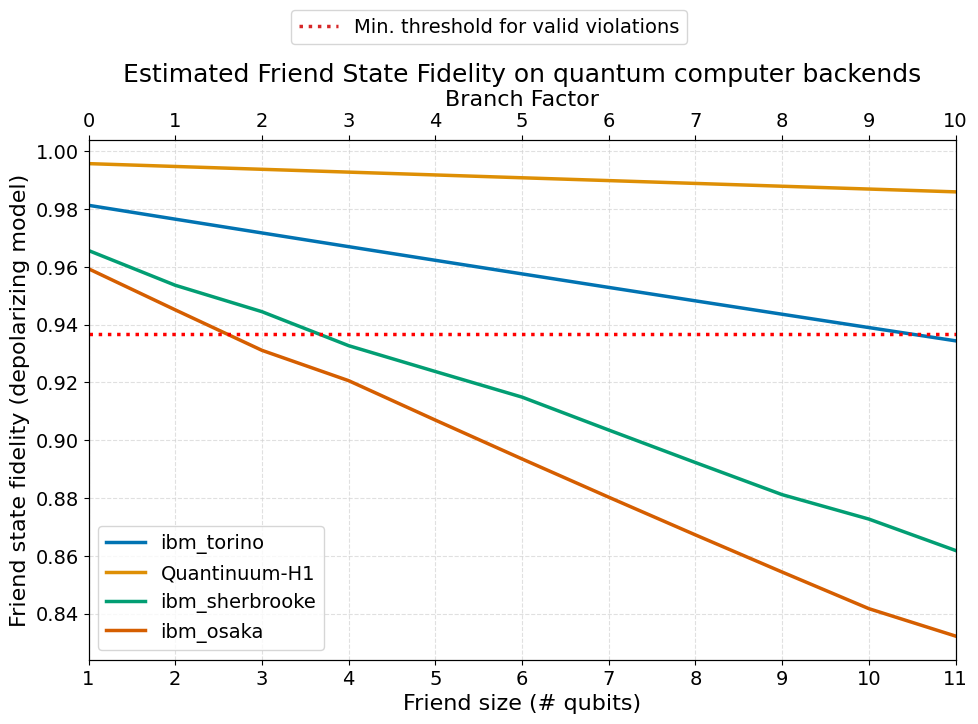

In [93]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.lines as mlines

plt.rcParams.update({'font.size': 14})  # Increase the default font size

# Set the colorblind palette
colors = sns.color_palette("colorblind")

# Create a plot with adjusted figsize
fig, ax1 = plt.subplots(figsize=(10, 7))  # Slightly larger figure to accommodate larger text

# Plot data on the main x-axis with thicker lines
xs = np.asarray(range(len(h1_fids))) + 1
ax1.plot(xs, torino_fids, label="ibm_torino", color=colors[0], linewidth=2.5)
ax1.plot(xs, h1_fids, label="Quantinuum-H1", color=colors[1], linewidth=2.5)
ax1.plot(xs, sherbrooke_fids, label="ibm_sherbrooke", color=colors[2], linewidth=2.5)
ax1.plot(xs, osaka_fids, label="ibm_osaka", color=colors[3], linewidth=2.5)

ax1.set_xticks(xs)
ax1.set_xlabel("Friend size (# qubits)", fontsize=16)
ax1.set_ylabel("Friend state fidelity (depolarizing model)", fontsize=16)

# Add grid lines
ax1.grid(True, linestyle='--', alpha=0.7, color='lightgray')

plt.legend(loc="lower left", fontsize=14)

# Create a secondary x-axis at the top
ax2 = ax1.twiny()

# Set the secondary x-axis labels
ax2.set_xlabel("Branch Factor", fontsize=16)
ax2.set_xticks(xs)
ax2.set_xticklabels(range(0, dd))

# Align the secondary x-axis with the main x-axis
ax1.set_xlim(1, dd)
ax2.set_xlim(1, dd)
ax2.set_xbound(ax1.get_xbound())

plt.title("Estimated Friend State Fidelity on quantum computer backends", fontsize=18)

plt.axhline(y=0.9366, color="r", linestyle=":", linewidth=2.5)

no_violation_handle = mlines.Line2D([], [], color="tab:red", linestyle="dotted", linewidth=2.5, label="Min. threshold for valid violations")

fig.legend([no_violation_handle], ["Min. threshold for valid violations"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize=14)

# Adjust the layout
plt.tight_layout()
plt.subplots_adjust(top=0.85)

# Save the figure
plt.savefig("friend_state_fids.pdf", bbox_inches="tight")
plt.show()

In [82]:
# ibm-sherbrooke:
sherbrooke_1qs = [46, 65, 72, 91, 98, 105, 124, 143, 162, 169, 188]
sherbrooke_2qs = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

# ibm-osaka
osaka_1qs = [46, 65, 84, 91, 110, 129, 148, 167, 186, 205, 212]
osaka_2qs = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

# ibm-torino
torino_1qs = [31, 37, 43, 49, 55, 61, 67, 73, 79, 85, 91]
torino_2qs = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
dd = len(torino_1qs)

# Quantinuum H1:
h1_1qs = [ 40.,  46.,  52.,  58.,  64.,  70.,  76.,  82.,  88.,  94., 100.,106., 112., 118., 124., 130.]
h1_2qs = [ 4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19.]
h1_1qs = h1_1qs[:dd]
h1_2qs = h1_2qs[:dd]

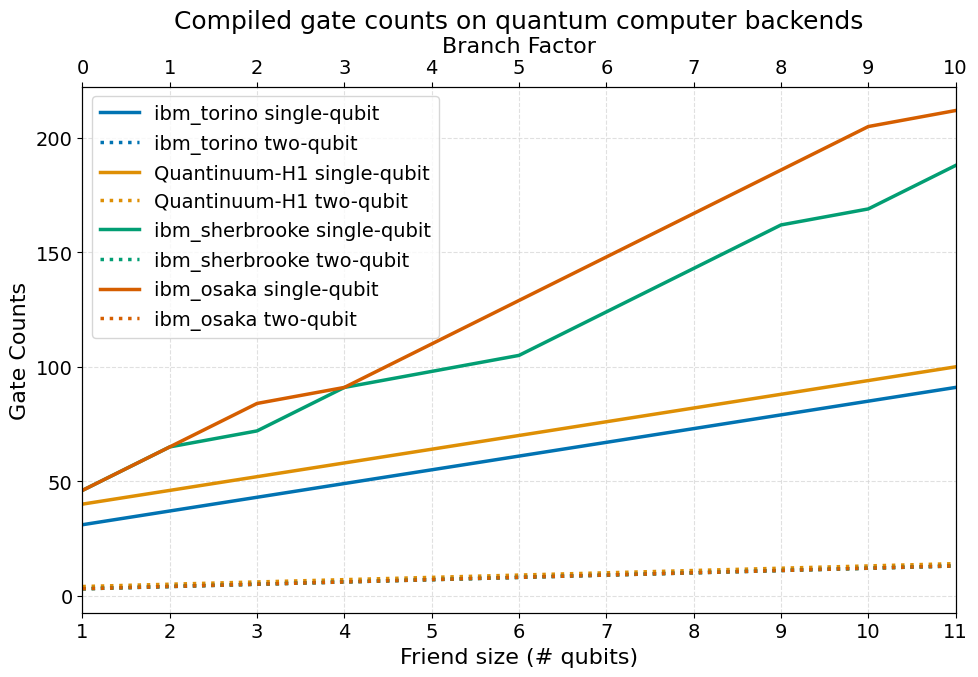

In [94]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.rcParams.update({'font.size': 14})  # Increase the default font size

# Set the colorblind palette
colors = sns.color_palette("colorblind")

# Create a plot with adjusted figsize
fig, ax1 = plt.subplots(figsize=(10, 7))  # Slightly larger figure to accommodate larger text

# Plot data on the main x-axis with thicker lines
xs = np.asarray(range(len(torino_2qs))) + 1
ax1.plot(xs, torino_1qs, label="ibm_torino single-qubit", color=colors[0], linewidth=2.5)
ax1.plot(xs, torino_2qs, label="ibm_torino two-qubit", color=colors[0], linestyle=":", linewidth=2.5)
ax1.plot(xs, h1_1qs, label="Quantinuum-H1 single-qubit", color=colors[1], linewidth=2.5)
ax1.plot(xs, h1_2qs, label="Quantinuum-H1 two-qubit", color=colors[1], linestyle=":", linewidth=2.5)
ax1.plot(xs, sherbrooke_1qs, label="ibm_sherbrooke single-qubit", color=colors[2], linewidth=2.5)
ax1.plot(xs, sherbrooke_2qs, label="ibm_sherbrooke two-qubit", color=colors[2], linestyle=":", linewidth=2.5)
ax1.plot(xs, osaka_1qs, label="ibm_osaka single-qubit", color=colors[3], linewidth=2.5)
ax1.plot(xs, osaka_2qs, label="ibm_osaka two-qubit", color=colors[3], linestyle=":", linewidth=2.5)

ax1.set_xticks(xs)
ax1.set_xlabel("Friend size (# qubits)", fontsize=16)
ax1.set_ylabel("Gate Counts", fontsize=16)

# Add grid lines
ax1.grid(True, linestyle='--', alpha=0.7, color='lightgray')

# Create a secondary x-axis at the top
ax2 = ax1.twiny()

# Set the secondary x-axis labels
ax2.set_xlabel("Branch Factor", fontsize=16)
ax2.set_xticks(xs)
ax2.set_xticklabels(range(0, dd))

# Align the secondary x-axis with the main x-axis
ax1.set_xlim(1, dd)
ax2.set_xlim(1, dd)
ax2.set_xbound(ax1.get_xbound())

plt.title("Compiled gate counts on quantum computer backends", fontsize=18)

# Add legend in the top left corner with larger font size
ax1.legend(loc="upper left", fontsize=14)

# Adjust the layout
plt.tight_layout()

# Save the figure
plt.savefig("gate_counts.pdf", bbox_inches="tight")
plt.show()